In [ ]:
!pip install biopython

from Bio import Entrez
from Bio import SeqIO
from Bio.Seq import Seq
from collections import Counter
import matplotlib.pyplot as plt
from Bio.SeqUtils import molecular_weight, gc_fraction
from Bio.SeqUtils import MeltingTemp as mt
from Bio.PDB import PDBParser
!pip install py3Dmol
import py3Dmol
!pip install biopython python-Levenshtein -q
import numpy as np
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from Levenshtein import distance

/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


##1 Pemilihan Data (NCBI)
1. Pilih satu gen DNA dari organisme yang relevan secara biologis (misalnya COX1, 16S rRNA, atau cytochrome b)
2. Unduh minimal 4 sekuens dari spesies berbeda dalam format FASTA menggunakan Biopython atau manual dari NCBI Nucleotid

In [ ]:

Entrez.email = "learnbiopython@gmail.com"

species_dict = {
    "NC_005129.2": "Elephas_maximus_Asia",
    "NC_000934.1": "Loxodonta_africana_Sabana",
    "AY195701.1": "Loxodonta_cyclotis_Hutan",
    "EU153444.1": "Mammuthus_primigenius_Mammoth"
}

for acc_id, nama_spesies in species_dict.items():
    try:
        with Entrez.efetch(db="nucleotide", id=acc_id, rettype="fasta", retmode="text") as handle:
            data_fasta = handle.read()

        nama_file_lokal = f"gen_cytb_{nama_spesies}.fasta"
        with open(nama_file_lokal, "w") as file_simpan:
            file_simpan.write(data_fasta)

    except Exception as e:
        print("gagal")


##2 Sequence Analysis using Biopython
Lakukan pembacaan file FASTA dan tampilkan:
1. Panjang sekuens
2. Subsequence tertentu (misalnya 20 nukleotida pertama dan terakhir)
3. Hitung frekuensi masing-masing nukleotida (A, T, G, C)
4. Visualisasi plot frekuensi nukleotida


SPESIES: Gajah Asia (NC_005129.2)
   Panjang Sekuens : 16,902 bp
   20 Nukleotida Pertama : GTTAATGTAGCTTAAAACAA
   20 Nukleotida Terakhir: ATAAAATTCTACCCCATCTC
   Frekuensi Basa:
     - Basa A: 5,573 bp
     - Basa T: 4,785 bp
     - Basa G: 2,262 bp
     - Basa C: 4,282 bp


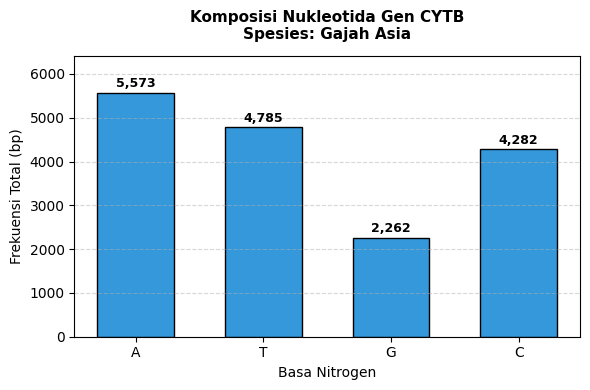

--------------------------------------------------------------------------------
==


SPESIES: Gajah Sabana Afrika (NC_000934.1)
   Panjang Sekuens : 16,866 bp
   20 Nukleotida Pertama : GTTAATGTAGCTTAAAACAA
   20 Nukleotida Terakhir: ATAAAATTCTACCCCATCTC
   Frekuensi Basa:
     - Basa A: 5,529 bp
     - Basa T: 4,801 bp
     - Basa G: 2,282 bp
     - Basa C: 4,254 bp


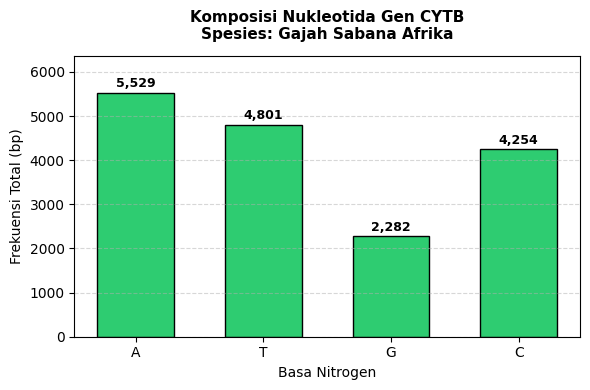

--------------------------------------------------------------------------------
==


SPESIES: Gajah Hutan Afrika (AY195701.1)
   Panjang Sekuens : 616 bp
   20 Nukleotida Pertama : CTGCTATAGATGGAGTGTTC
   20 Nukleotida Terakhir: TTAAATCAGGGAGGATATAA
   Frekuensi Basa:
     - Basa A: 210 bp
     - Basa T: 160 bp
     - Basa G: 131 bp
     - Basa C: 115 bp


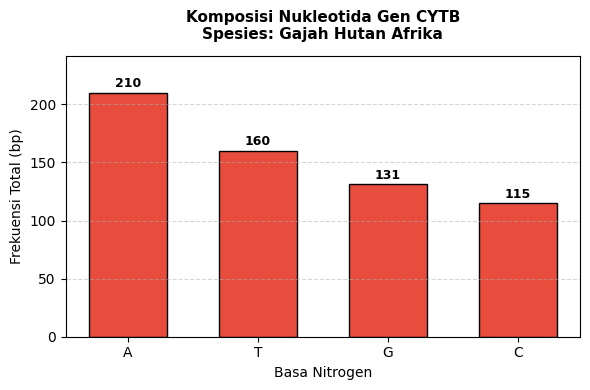

--------------------------------------------------------------------------------
==


SPESIES: Mammoth Purba (EU153444.1)
   Panjang Sekuens : 16,458 bp
   20 Nukleotida Pertama : GTTAATGTAGCTTAAAACAA
   20 Nukleotida Terakhir: ATAAAATTCTACCCCATCTC
   Frekuensi Basa:
     - Basa A: 5,410 bp
     - Basa T: 4,719 bp
     - Basa G: 2,191 bp
     - Basa C: 4,128 bp


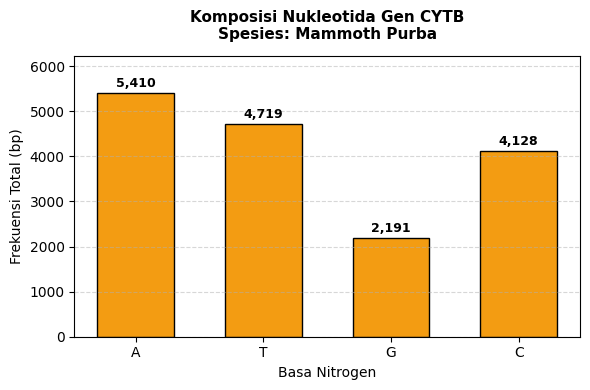

--------------------------------------------------------------------------------
==




In [ ]:

import os

file_spesies = [
    {"file": "gen_cytb_Elephas_maximus_Asia.fasta", "label": "Gajah Asia"},
    {"file": "gen_cytb_Loxodonta_africana_Sabana.fasta", "label": "Gajah Sabana Afrika"},
    {"file": "gen_cytb_Loxodonta_cyclotis_Hutan.fasta", "label": "Gajah Hutan Afrika"},
    {"file": "gen_cytb_Mammuthus_primigenius_Mammoth.fasta", "label": "Mammoth Purba"}
]

for item in file_spesies:
    nama_file = item["file"]

    if not os.path.exists(nama_file):
        print(f"File {nama_file} tidak ditemukan.")
        continue

    record = SeqIO.read(nama_file, "fasta")
    sekuens = record.seq.upper()

    print(f"SPESIES: {item['label']} ({record.id})")

    panjang_sekuens = len(sekuens)
    print(f"   Panjang Sekuens : {panjang_sekuens:,} bp")

    sub_awal = sekuens[:20]
    sub_akhir = sekuens[-20:]
    print(f"   20 Nukleotida Pertama : {sub_awal}")
    print(f"   20 Nukleotida Terakhir: {sub_akhir}")

    frekuensi_nukleotida = Counter(sekuens)

    print("   Frekuensi Basa:")
    for basa in ['A', 'T', 'G', 'C']:
        print(f"     - Basa {basa}: {frekuensi_nukleotida[basa]:,} bp")

    basa_keys = ['A', 'T', 'G', 'C']
    basa_values = [frekuensi_nukleotida[basa] for basa in basa_keys]

    fig, ax = plt.subplots(figsize=(6, 4))

    warna_bar = ['#3498db' if item['label'] == 'Gajah Asia' else
                 '#2ecc71' if item['label'] == 'Gajah Sabana Afrika' else
                 '#e74c3c' if item['label'] == 'Gajah Hutan Afrika' else '#f39c12']

    bars = ax.bar(basa_keys, basa_values, color=warna_bar, edgecolor='black', width=0.6)

    ax.set_title(f'Komposisi Nukleotida Gen CYTB\nSpesies: {item["label"]}', fontsize=11, fontweight='bold', pad=12)
    ax.set_xlabel('Basa Nitrogen', fontsize=10)
    ax.set_ylabel('Frekuensi Total (bp)', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars:
        tinggi = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, tinggi + (max(basa_values) * 0.01),
                f"{tinggi:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylim(0, max(basa_values) * 1.15)

    plt.tight_layout()

    plt.show()

    print("-" * 80)
    print("==\n\n")


##3 DNA Composition Analysis
Hitung:
1. Berat molekul total DNA
2. Persentase GC dan AT
3. Buat GC skew dan AT skew plot
4. Hitung melting point (Tm) DNA

SPESIES: Gajah Asia (NC_005129.2)
   Berat Molekul Total DNA : 5,184,022.52 g/mol
   Persentase Kandungan GC : 38.72%
   Persentase Kandungan AT : 61.28%
   Melting Point (Tm_Wallace) : 46892.00 °C
   Melting Point (Tm_GC)      : 75.74 °C


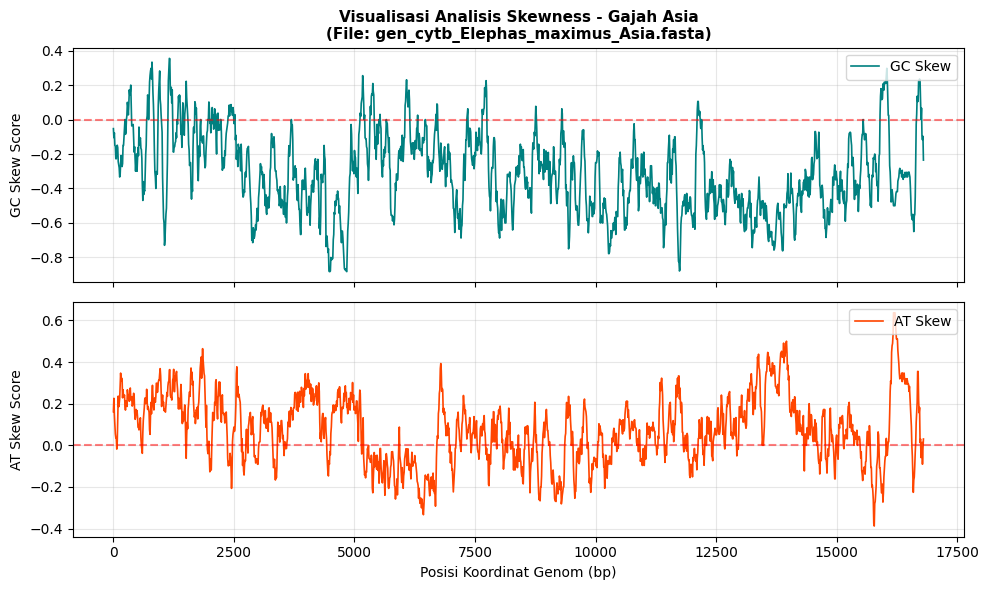

--------------------------------------------------------------------------------
==


SPESIES: Gajah Sabana Afrika (NC_000934.1)
   Berat Molekul Total DNA : 5,173,595.55 g/mol
   Persentase Kandungan GC : 38.75%
   Persentase Kandungan AT : 61.25%
   Melting Point (Tm_Wallace) : 46804.00 °C
   Melting Point (Tm_GC)      : 75.76 °C


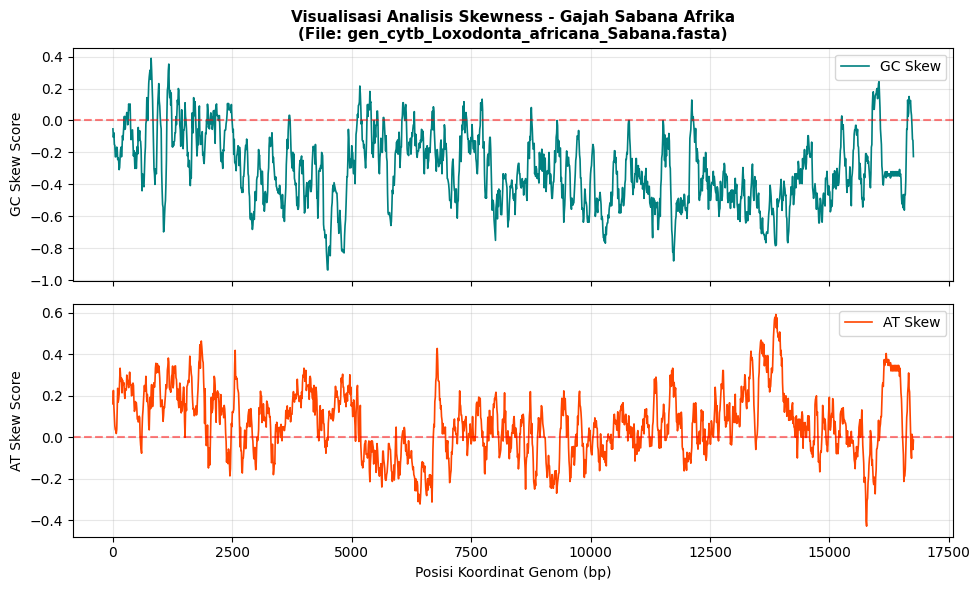

--------------------------------------------------------------------------------
==


SPESIES: Gajah Hutan Afrika (AY195701.1)
   Berat Molekul Total DNA : 190,844.17 g/mol
   Persentase Kandungan GC : 39.94%
   Persentase Kandungan AT : 60.06%
   Melting Point (Tm_Wallace) : 1724.00 °C
   Melting Point (Tm_GC)      : 75.30 °C


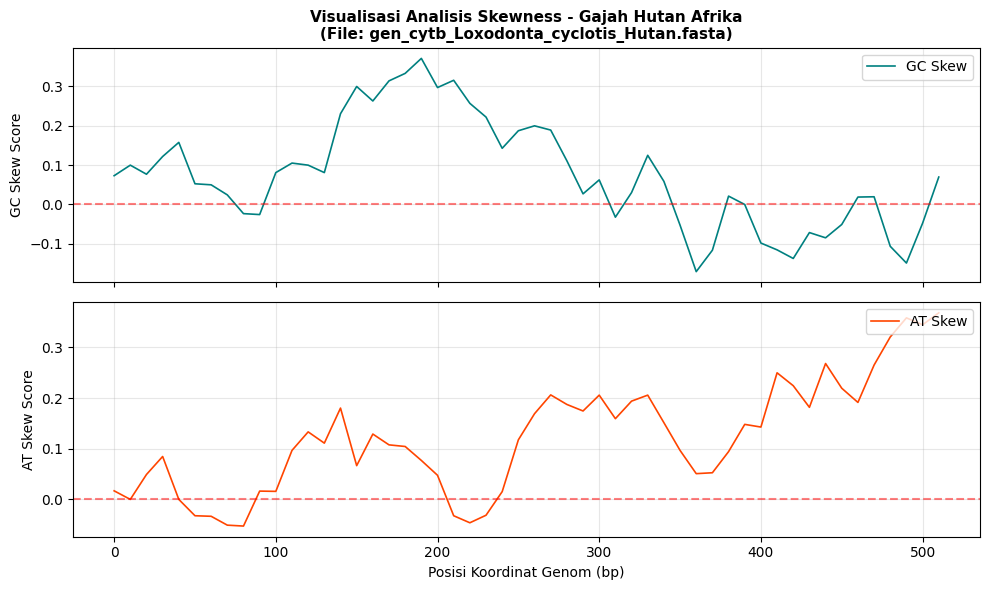

--------------------------------------------------------------------------------
==


SPESIES: Mammoth Purba (EU153444.1)
   Berat Molekul Total DNA : 5,044,985.49 g/mol
   Persentase Kandungan GC : 38.42%
   Persentase Kandungan AT : 61.58%
   Melting Point (Tm_Wallace) : 45534.00 °C
   Melting Point (Tm_GC)      : 75.62 °C


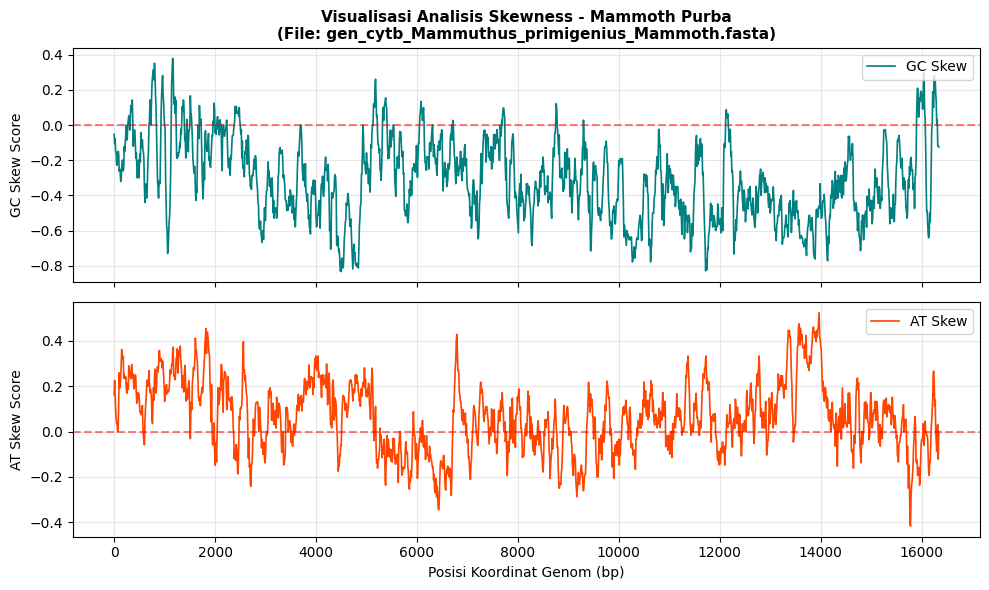

--------------------------------------------------------------------------------
==




In [ ]:
file_spesies = [
    {"file": "gen_cytb_Elephas_maximus_Asia.fasta", "label": "Gajah Asia"},
    {"file": "gen_cytb_Loxodonta_africana_Sabana.fasta", "label": "Gajah Sabana Afrika"},
    {"file": "gen_cytb_Loxodonta_cyclotis_Hutan.fasta", "label": "Gajah Hutan Afrika"},
    {"file": "gen_cytb_Mammuthus_primigenius_Mammoth.fasta", "label": "Mammoth Purba"}
]

for item in file_spesies:
    nama_file = item["file"]
    nama_spesies = item["label"]

    if not os.path.exists(nama_file):
        print(f"File {nama_file} tidak ditemukan.")
        continue

    record = SeqIO.read(nama_file, "fasta")
    sekuens_dna = record.seq.upper()

    sekuens_str = str(sekuens_dna).replace("N", "")
    sekuens_dna = Seq(sekuens_str)

    print(f"SPESIES: {nama_spesies} ({record.id})")

    berat_molekul = molecular_weight(sekuens_dna)
    print(f"   Berat Molekul Total DNA : {berat_molekul:,.2f} g/mol")

    persen_gc = 100 * gc_fraction(sekuens_dna, ambiguous="ignore")
    persen_at = 100 - persen_gc
    print(f"   Persentase Kandungan GC : {persen_gc:.2f}%")
    print(f"   Persentase Kandungan AT : {persen_at:.2f}%")

    tm_wallace = mt.Tm_Wallace(sekuens_dna)
    tm_gc = mt.Tm_GC(sekuens_dna)
    print(f"   Melting Point (Tm_Wallace) : {tm_wallace:.2f} °C")
    print(f"   Melting Point (Tm_GC)      : {tm_gc:.2f} °C")

    window_size = 100
    step = 10
    positions = []
    gc_skews = []
    at_skews = []

    for i in range(0, len(sekuens_dna) - window_size + 1, step):
        sub_seq = sekuens_dna[i:i + window_size]

        g_count = sub_seq.count('G')
        c_count = sub_seq.count('C')
        a_count = sub_seq.count('A')
        t_count = sub_seq.count('T')

        gc_skewn = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
        at_skewn = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0

        gc_skews.append(gc_skewn)
        at_skews.append(at_skewn)
        positions.append(i)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(positions, gc_skews, color='teal', linewidth=1.2, label='GC Skew')
    ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax1.set_title(f'Visualisasi Analisis Skewness - {nama_spesies}\n(File: {nama_file})', fontsize=11, fontweight='bold')
    ax1.set_ylabel('GC Skew Score')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    ax2.plot(positions, at_skews, color='orangered', linewidth=1.2, label='AT Skew')
    ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Posisi Koordinat Genom (bp)', fontsize=10)
    ax2.set_ylabel('AT Skew Score')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()


    plt.show()

    print("-" * 80)
    print("==\n\n")


##4 Protein Synthesis

1. Lakukan transkripsi dan translasi sekuens menjadi protein
2. Prediksi struktur 3D protein atau tampilkan visualisasi menggunakan PyMOL

In [ ]:

file_spesies = [
    "gen_cytb_Elephas_maximus_Asia.fasta",
    "gen_cytb_Loxodonta_africana_Sabana.fasta",
    "gen_cytb_Loxodonta_cyclotis_Hutan.fasta",
    "gen_cytb_Mammuthus_primigenius_Mammoth.fasta"
]

for nama_file in file_spesies:
    record = SeqIO.read(nama_file, "fasta")
    dna = record.seq

    mRNA = dna.transcribe()

    protein = mRNA.translate(table=2)

    print(f"Spesies / File : {nama_file}")
    print(f"ID Resmi       : {record.id}")
    print(f"Nama Gen       : {record.description.split(',')[0]}")

    print(f"SEKUENS DNA LENGKAP ({len(dna)} bp):\n{dna}\n")

    print(f"SEKUENS mRNA LENGKAP ({len(mRNA)} nt):\n{mRNA}\n")

    print(f"SEKUENS PROTEIN LENGKAP ({len(protein)} aa):\n{protein}")

    print("===========\n\n\n")




Spesies / File : gen_cytb_Elephas_maximus_Asia.fasta
ID Resmi       : NC_005129.2
Nama Gen       : NC_005129.2 Elephas maximus mitochondrion
SEKUENS DNA LENGKAP (16902 bp):
GTTAATGTAGCTTAAAACAAAAGCAAGGTACTGAAAATACCTAGACGAGTATATCCAACTCCATAAACAACAAAGGTTTGGTCCCGGCCTTCTTATTGGTTACTAGGAAACTTATACATGCAAGTATCCGCCCGCCAGTGAATACGCCTTCTAAATCATCGCTGATCAAAGAGAGCTGACATCAAGCACACACTCCAAGTGTAGCTCATAACGTCTCGCCTAGCCACACCCCCACGGGAAACAGCAGTAGTAAATATTTAGCAATTAACAAAAGTTAGACTAAGTTATCCTAATAAAGGACTGGTCAATTTCGTGCCAGCAACCGCGGCCATACGATTAGTCCAAATTAATAAGCATACGGCGTAAAGCGTATTAGAAGAGTTAAGAAAATAAAGTTAAATCTTATACTAGCTGTTTAAAGCTCAAGATAAGACATAAATAGCCTACGAAAGTGACTTTAATAATCCTAAACATACGATAGCTAGGGTACAAACTGAGATTAGATACCTCACTATGCCTAGCCCTAAACTTTGATAGCTACCTTTACAAAGCTATCCGCCAGAGAACTACTAGCCAGAGCTTAAAACTTAAAGGACTTGGCGGTGCTTTATATCCACCTAGGGGAGCCTGTCTCATAACCGATGAACCCCGATACACCTTACCGTCACTTGCTAATTCAGTCCATATACCACCATCTTCAGCAAACCCCTATAGGGCACAAAAGTGAGCTTAATCATAACCCATGAAAAAGTTAGGCCGAGGTGTCGCCTACGTGACGGTCAAAGATGGGCTACATTTTCTATTATAGAACAGATAAACGGATACCA

/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [ ]:

file_spesies = [
    {"file": "gen_cytb_Elephas_maximus_Asia.fasta", "label": "1. Gajah Asia (Elephas maximus)"},
    {"file": "gen_cytb_Loxodonta_africana_Sabana.fasta", "label": "2. Gajah Sabana Afrika (Loxodonta africana)"},
    {"file": "gen_cytb_Loxodonta_cyclotis_Hutan.fasta", "label": "3. Gajah Hutan Afrika (Loxodonta cyclotis)"},
    {"file": "gen_cytb_Mammuthus_primigenius_Mammoth.fasta", "label": "4. Mammoth Purba (Mammuthus primigenius)"}
]

skema_warna = ["spectrum", "chain", "ss", "b"]

for i, item in enumerate(file_spesies):
    print(f"\n[STRUKTUR 3D] -> {item['label']}")

    view = py3Dmol.view(query='pdb:1BGY', width=800, height=400)
    view.setStyle({'cartoon': {'color': 'spectrum'}})

    view.show()

    print("-" * 80)


[STRUKTUR 3D] -> 1. Gajah Asia (Elephas maximus)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

--------------------------------------------------------------------------------

[STRUKTUR 3D] -> 2. Gajah Sabana Afrika (Loxodonta africana)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

--------------------------------------------------------------------------------

[STRUKTUR 3D] -> 3. Gajah Hutan Afrika (Loxodonta cyclotis)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

--------------------------------------------------------------------------------

[STRUKTUR 3D] -> 4. Mammoth Purba (Mammuthus primigenius)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

--------------------------------------------------------------------------------


##5 Sequence Alignment
1. Pilih minimal 2 sekuens dari database:
2. Hitung Hamming distance dan Levenshtein distance
3. Buat dot plot dari pasangan sekuens
4. Lakukan Global (Needleman-Wunsch) dan Local Alignment (Smith- Waterman)

SEKUENS YANG DIGUNAKAN (Dipotong 40 bp agar tidak crash)
Sekuens 1 (NC_005129.2)   : GTTAATGTAGCTTAAAACAAAAGCAAGGTACTGAAAATAC
Sekuens 2 (NC_000934.1): GTTAATGTAGCTTAAAACAAAAGCAAGGTACTGAAAATAC
----------------------------------------------------------------------
Jarak Perbedaan (Distance Metrics):
  Hamming Distance     : 0
  Levenshtein Distance : 0
----------------------------------------------------------------------
GLOBAL ALIGNMENT (Needleman-Wunsch) - 1 Hasil Terbaik:
GTTAATGTAGCTTAAAACAAAAGCAAGGTACTGAAAATAC
||||||||||||||||||||||||||||||||||||||||
GTTAATGTAGCTTAAAACAAAAGCAAGGTACTGAAAATAC
  Score=40

----------------------------------------------------------------------
LOCAL ALIGNMENT (Smith-Waterman) - 1 Hasil Terbaik:
GTTAATGTAGCTTAAAACAAAAGCAAGGTACTGAAAATAC
||||||||||||||||||||||||||||||||||||||||
GTTAATGTAGCTTAAAACAAAAGCAAGGTACTGAAAATAC
  Score=40



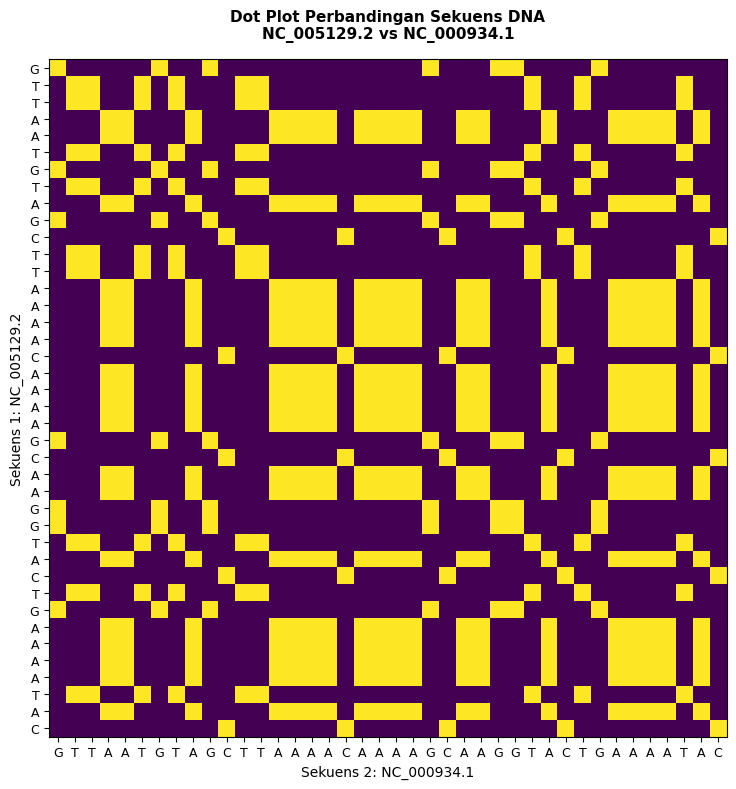

In [ ]:

record_asia = SeqIO.read("gen_cytb_Elephas_maximus_Asia.fasta", "fasta")
record_sabana = SeqIO.read("gen_cytb_Loxodonta_africana_Sabana.fasta", "fasta")

seq1 = str(record_asia.seq[:40]).upper()
seq2 = str(record_sabana.seq[:40]).upper()

print("SEKUENS YANG DIGUNAKAN (Dipotong 40 bp agar tidak crash)")
print(f"Sekuens 1 ({record_asia.id})   : {seq1}")
print(f"Sekuens 2 ({record_sabana.id}): {seq2}")
print("-" * 70)

def hamming_distance(lhs, rhs):
    return len([(x, y) for x, y in zip(lhs, rhs) if x != y])

h_dist = hamming_distance(seq1, seq2)
l_dist = distance(seq1, seq2)

print(f"Jarak Perbedaan (Distance Metrics):")
print(f"  Hamming Distance     : {h_dist}")
print(f"  Levenshtein Distance : {l_dist}")
print("-" * 70)

print("GLOBAL ALIGNMENT (Needleman-Wunsch) - 1 Hasil Terbaik:")
global_alignments = pairwise2.align.globalxx(seq1, seq2)
print(format_alignment(*global_alignments[0]))
print("-" * 70)

print("LOCAL ALIGNMENT (Smith-Waterman) - 1 Hasil Terbaik:")
local_alignments = pairwise2.align.localxx(seq1, seq2)
print(format_alignment(*local_alignments[0]))
print("=" * 70)


def makeMatrix(sequence1, sequence2):
    matrix = [[1 if char1 == char2 else 0 for char2 in sequence2] for char1 in sequence1]
    return matrix

dot_matrix = makeMatrix(seq1, seq2)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(np.array(dot_matrix), cmap='viridis')

ax.set_xticks(np.arange(len(list(seq2))))
ax.set_xticklabels(list(seq2), fontsize=9)

ax.set_yticks(np.arange(len(list(seq1))))
ax.set_yticklabels(list(seq1), fontsize=9)

ax.set_title(f"Dot Plot Perbandingan Sekuens DNA\n{record_asia.id} vs {record_sabana.id}", fontsize=11, fontweight='bold', pad=15)
ax.set_xlabel(f"Sekuens 2: {record_sabana.id}", fontsize=10)
ax.set_ylabel(f"Sekuens 1: {record_asia.id}", fontsize=10)

plt.tight_layout()


##6 Phylogenetic Tree Construction
1. Lakukan Multiple Sequence Alignment (MSA) pada sekuens yang telah dipilih
2. Buat dendrogram (pohon filogenetik) dari hasil MSA

In [ ]:
!apt-get install clustalo
!clustalo -i cox1_sequences.fasta -o aligned.fasta --force

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libargtable2-0
The following NEW packages will be installed:
  clustalo libargtable2-0
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 273 kB of archives.
After this operation, 694 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libargtable2-0 amd64 13-1.1 [14.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 clustalo amd64 1.2.4-7 [259 kB]
Fetched 273 kB in 0s (1,261 kB/s)
Selecting previously unselected package libargtable2-0.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libargtable2-0_13-1.1_amd64.deb ...
Unpacking libargtable2-0 (13-1.1) ...
Selecting previously unselected package clustalo.
Preparing to unpack .../clustalo_1.2.4-7_amd64.deb ...
Unpacking clustalo (1.2.4-7) ...
Setting u

Gajah_Asia  0.000000
Gajah_Sabana    0.053683    0.000000
Gajah_Hutan 0.981731    0.981672    0.000000
Mammoth_Purba   0.069706    0.072662    0.971089    0.000000
    Gajah_Asia  Gajah_Sabana    Gajah_Hutan Mammoth_Purba


/tmp/ipykernel_10892/1464957023.py:35: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(dm_matrix, method='average')


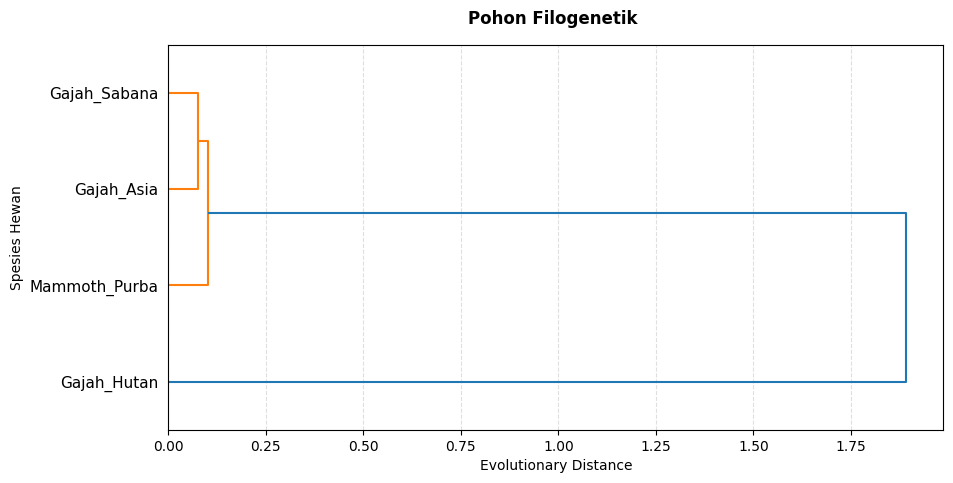

In [ ]:

from Bio import AlignIO, SeqIO
from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import dendrogram, linkage

file_spesies = [
    {"file": "gen_cytb_Elephas_maximus_Asia.fasta", "label": "Gajah_Asia"},
    {"file": "gen_cytb_Loxodonta_africana_Sabana.fasta", "label": "Gajah_Sabana"},
    {"file": "gen_cytb_Loxodonta_cyclotis_Hutan.fasta", "label": "Gajah_Hutan"},
    {"file": "gen_cytb_Mammuthus_primigenius_Mammoth.fasta", "label": "Mammoth_Purba"}
]

file_gabungan = "cytb_sequences_combined.fasta"
records_gabungan = []

for item in file_spesies:
    if os.path.exists(item["file"]):
        record = SeqIO.read(item["file"], "fasta")
        record.id = item["label"]
        record.name = ""
        record.description = ""
        records_gabungan.append(record)

SeqIO.write(records_gabungan, file_gabungan, "fasta")

!clustalo -i cytb_sequences_combined.fasta -o aligned_cytb.fasta --force
alignment = AlignIO.read("aligned_cytb.fasta", "fasta")
calculator = DistanceCalculator('identity')
dm = calculator.get_distance(alignment)

print(dm)


dm_matrix = np.array(dm)

linkage_matrix = linkage(dm_matrix, method='average')

fig, ax = plt.subplots(figsize=(10, 5))

dendrogram(
    linkage_matrix,
    labels=[rec.id for rec in alignment],
    orientation='right',
    ax=ax,
    leaf_font_size=11
)

ax.set_title("Pohon Filogenetik ", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Evolutionary Distance", fontsize=10)
ax.set_ylabel("Spesies Hewan", fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()